In [1]:
import sys
print(sys.version)
print(sys.executable)

3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
c:\Users\shyam\anaconda3\python.exe


In [2]:
import shap
print(shap.__version__)

0.46.0


In [3]:
import pandas as pd
import shap
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

In [4]:
import numpy as np
import shap

print(np.__version__)
print(shap.__version__)

1.26.4
0.46.0


In [5]:
import pandas as pd
import shap
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_csv(
    r"C:\Users\shyam\OneDrive\Documents\customer-churn-ltv-engine\data\raw\telco_churn.csv"
)

print(df.shape)

(7043, 33)


In [7]:
# Remove unwanted columns

df = df.drop([
    'CustomerID',
    'Country',
    'State',
    'City',
    'Lat Long',
    'Churn Reason'
], axis=1)

print(df.shape)

(7043, 27)


In [8]:
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

df['Total Charges'] = df['Total Charges'].fillna(
    df['Total Charges'].median()
)

print(df['Total Charges'].isnull().sum())

0


In [9]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.shape)

(7043, 38)


In [10]:
X = df_encoded.drop([
    'Churn Value',
    'Churn Label_Yes',
    'Churn Score',
    'CLTV'
], axis=1)

y = df_encoded['Churn Value']

print(X.shape)
print(y.shape)

(7043, 34)
(7043,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5634, 34)
(1409, 34)


In [12]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [13]:
print(type(xgb_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [14]:
import xgboost
print(xgboost.__version__)

3.2.0


In [16]:
print(type(xgb_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [18]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                            Feature  Importance
14     Internet Service_Fiber optic    0.314463
29                Contract_Two year    0.232560
28                Contract_One year    0.087185
15              Internet Service_No    0.077565
10                   Dependents_Yes    0.054572
4                     Tenure Months    0.026281
27             Streaming Movies_Yes    0.020983
32  Payment Method_Electronic check    0.014762
11                Phone Service_Yes    0.014216
23                 Tech Support_Yes    0.013436


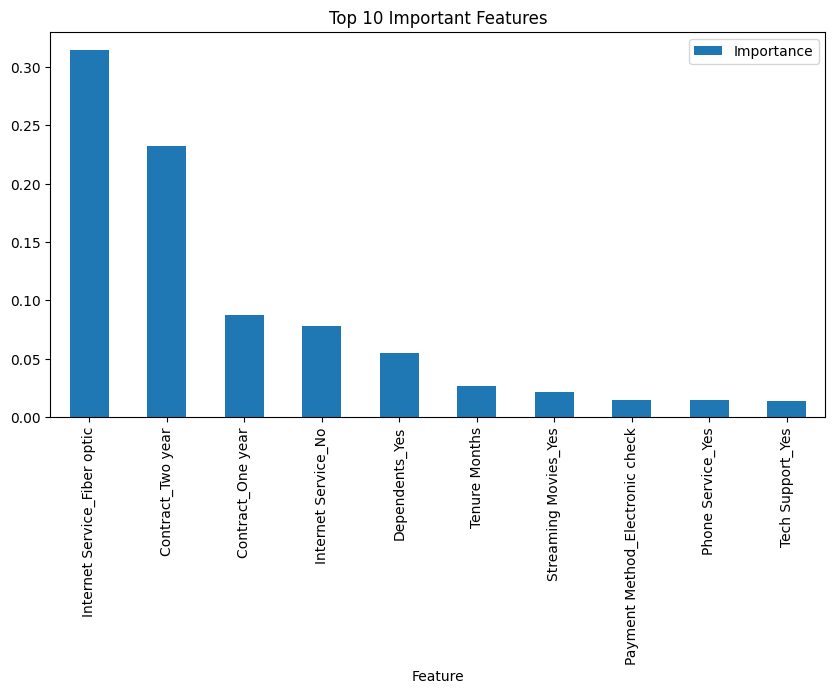

In [19]:
import matplotlib.pyplot as plt

importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Important Features")
plt.show()

## Business Insights

1. Customers using Fiber Optic Internet are more likely to churn.
2. Customers with One-Year and Two-Year contracts are less likely to churn.
3. Customers without dependents show higher churn behavior.
4. Tenure is an important factor; long-term customers are more likely to stay.
5. Customers using Electronic Check payment methods have higher churn risk.
6. Customers with Tech Support subscriptions are more likely to remain loyal.

In [15]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import os

BASE_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(BASE_DIR)  # adjust if needed — should point to customer-churn-ltv-engine

file_path = os.path.join(PROJECT_ROOT, "data", "raw", "telco_churn.csv")
model_path = os.path.join(PROJECT_ROOT, "models", "random_forest_model.pkl")
reports_path = os.path.join(PROJECT_ROOT, "reports")

os.makedirs(reports_path, exist_ok=True)

df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df = df.dropna()

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop([
    'Churn Value',
    'Churn Label_Yes',
    'Churn Score',
    'CLTV',
    'Count',
    'Zip Code',
    'Latitude',
    'Longitude'
], axis=1)

y = df_encoded['Churn Value']

rf_model = joblib.load(model_path)

print("✅ Data and model loaded")
print("X shape:", X.shape)

KeyError: "['Churn Label_Yes'] not found in axis"

In [16]:
print([col for col in df_encoded.columns if 'Churn' in col])

['Churn Value', 'Churn Score', 'Churn Reason_Attitude of support person', 'Churn Reason_Competitor had better devices', 'Churn Reason_Competitor made better offer', 'Churn Reason_Competitor offered higher download speeds', 'Churn Reason_Competitor offered more data', 'Churn Reason_Deceased', "Churn Reason_Don't know", 'Churn Reason_Extra data charges', 'Churn Reason_Lack of affordable download/upload speed', 'Churn Reason_Lack of self-service on Website', 'Churn Reason_Limited range of services', 'Churn Reason_Long distance charges', 'Churn Reason_Moved', 'Churn Reason_Network reliability', 'Churn Reason_Poor expertise of online support', 'Churn Reason_Poor expertise of phone support', 'Churn Reason_Price too high', 'Churn Reason_Product dissatisfaction', 'Churn Reason_Service dissatisfaction']


In [17]:
print(df.columns.tolist())

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [19]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import os

BASE_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(BASE_DIR)

file_path = os.path.join(PROJECT_ROOT, "data", "raw", "telco_churn.csv")
model_path = os.path.join(PROJECT_ROOT, "models", "random_forest_model.pkl")
reports_path = os.path.join(PROJECT_ROOT, "reports")
os.makedirs(reports_path, exist_ok=True)

df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# Drop identifier / leakage / geographic columns FIRST
df = df.drop([
    'CustomerID', 'Count', 'Country', 'State', 'City',
    'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
    'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason'
], axis=1)

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df = df.dropna()

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(['Churn Value'], axis=1)
y = df_encoded['Churn Value']

rf_model = joblib.load(model_path)

print("✅ Data and model loaded")
print("X shape:", X.shape)

✅ Data and model loaded
X shape: (7032, 30)


In [20]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X)

print("Type:", type(shap_values))
if isinstance(shap_values, list):
    print("Number of classes:", len(shap_values))
    print("Shape of class 1 array:", shap_values[1].shape)
else:
    print("Shape:", shap_values.shape)

Type: <class 'numpy.ndarray'>
Shape: (7032, 30, 2)


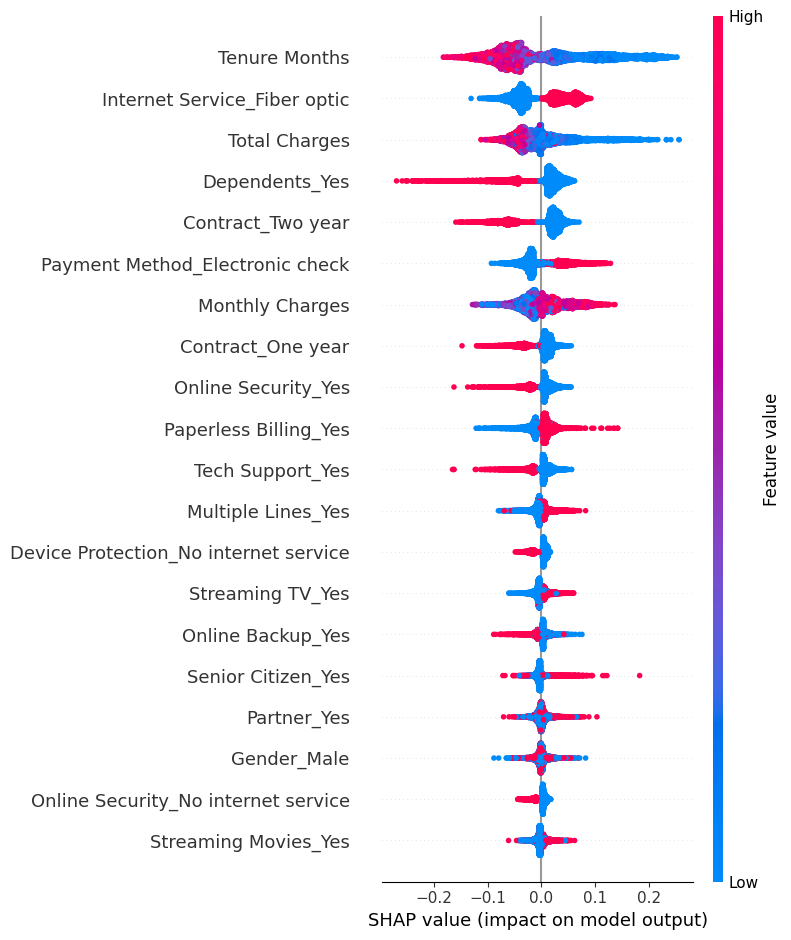

✅ Summary plot saved to reports/shap_summary_plot.png


In [21]:
shap_values_churn = shap_values[:, :, 1]

plt.figure()
shap.summary_plot(shap_values_churn, X, show=False)
plt.tight_layout()
plt.savefig(os.path.join(reports_path, "shap_summary_plot.png"), dpi=150, bbox_inches="tight")
plt.show()

print("✅ Summary plot saved to reports/shap_summary_plot.png")

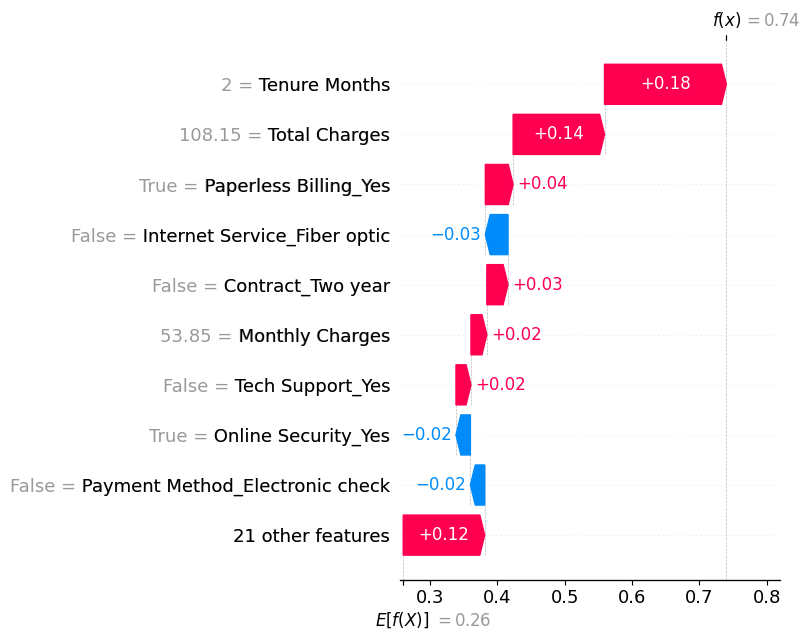

✅ Waterfall plot saved to reports/shap_waterfall_customer0.png
Actual churn label for this customer: 1
Model's predicted probability: 0.74


In [23]:
sample_idx = 0  # pick the first row in X; change this to look at a different customer

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_churn[sample_idx],
        base_values=explainer.expected_value[1],
        data=X.iloc[sample_idx].values,
        feature_names=X.columns.tolist()
    ),
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(reports_path, "shap_waterfall_customer0.png"), dpi=150, bbox_inches="tight")
plt.show()

print("✅ Waterfall plot saved to reports/shap_waterfall_customer0.png")
print("Actual churn label for this customer:", y.iloc[sample_idx])
print("Model's predicted probability:", rf_model.predict_proba(X.iloc[[sample_idx]])[0][1])